# Analisi dei Dati Meteorologici di Londra — Classificazione Binaria
## 1. Setup e Importazione Librerie
In questa cella configuriamo l'ambiente di runtime installando i pacchetti non nativi di Google Colab (`xgboost` e `yellowbrick`) e importiamo i moduli di Scikit-Learn necessari per la costruzione delle pipeline, il tuning e la valutazione dei modelli.



In [ ]:
# Installazione delle librerie necessarie
!pip install xgboost yellowbrick -q

# Import delle librerie di base e visualizzazione
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Impostazioni grafiche globali
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

# Import moduli Scikit-Learn e librerie ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit, learning_curve
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, f1_score, precision_recall_curve
)

from xgboost import XGBClassifier
from yellowbrick.classifier import ROCAUC, PrecisionRecallCurve
from yellowbrick.model_selection import LearningCurve

## 2. Caricamento del Dataset e Normalizzazione
Carichiamo il file sorgente `london_weather.csv` all'interno dell'ambiente virtuale. Subito dopo, normalizziamo i nomi delle colonne convertendoli in minuscolo ed eliminando spazi vuoti o caratteri speciali.

In [ ]:
data = pd.read_csv('/content/london_weather.csv', sep=',')

# Normalizzazione formale dei nomi delle colonne
data.columns = (
    data.columns.str.strip().str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[^\w]', '_', regex=True)
)
print("✅ Dataset caricato con successo.")
print("Colonne disponibili:", data.columns.tolist())

✅ Dataset caricato con successo.
Colonne disponibili: ['date', 'cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth']


## 3. Pulizia dei Dati e Gestione Missing Values
Gestiamo i valori mancanti (*Null/NaN*) imputandoli con la media storica calcolata sulla rispettiva colonna. Successivamente, convertiamo la variabile `date` nel tipo nativo `datetime64` ed verifichiamo la presenza di record duplicati.

In [ ]:
columns_to_fill = [
    "cloud_cover", "sunshine", "global_radiation",
    "max_temp", "mean_temp", "min_temp",
    "precipitation", "pressure", "snow_depth"
]

# Imputazione dei valori mancanti con la media di colonna
for col in columns_to_fill:
    data[col] = data[col].fillna(data[col].mean())

# Parsing del campo temporale
data['date'] = pd.to_datetime(data['date'], format="%Y%m%d")
print(f"Numero di record duplicati rilevati: {data.duplicated().sum()}")

Numero di record duplicati rilevati: 0


## 4. Feature Engineering (Lag Features e Stagionalità)
Estraiamo le componenti temporali (giorno, mese, anno) e costruiamo le **lag features** (valore al giorno precedente tramite `shift(1)`) per le precipitazioni, le ore di sole e la copertura nuvolosa. Calcoliamo inoltre la media mobile pluviometrica sui 3 giorni precedenti (`precip_ma3`). Infine, applichiamo il One-Hot Encoding sui mesi per catturare gli effetti stagionali.

In [ ]:
# Estrazione componenti della data
data['day']   = data['date'].dt.day
data['month'] = data['date'].dt.month
data['year']  = data['date'].dt.year

# Costruzione delle feature storiche (giorno precedente) per evitare data leakage
data['precip_lag1'] = data['precipitation'].shift(1).fillna(0)
data['sunshine_lag1'] = data['sunshine'].shift(1).fillna(0)
data['cloud_lag1']    = data['cloud_cover'].shift(1).fillna(0)

# Media mobile delle precipitazioni sui 3 giorni precedenti
data['precip_ma3'] = (
    data['precipitation']
    .shift(1)
    .rolling(window=3, min_periods=1)
    .mean()
    .fillna(0)
)

# Codifica One-Hot Encoding per la stagionalità mensile
data = pd.get_dummies(data, columns=['month'], prefix='month')
print("✅ Feature engineering completato.")

✅ Feature engineering completato.


## 5. Creazione del Target Binario
Definiamo la variabile obiettivo booleana `y` (Pioggia / No Pioggia). Per evitare rigorosamente fenomeni di Target Leakage, isoliamo il Training Set storico (giorni antecedenti al 2019) e calcoliamo la soglia del **60° percentile** esclusivamente su questa porzione di dati. Il valore fisso ottenuto viene poi applicato come regola di etichettatura all'intero dataset. Infine, il DataFrame viene ordinato cronologicamente.

In [ ]:
# ============================================================================
# Creazione del target binario
# ============================================================================
# 1. Isoliamo le precipitazioni del solo Training Set storico (pre-2019)
train_precipitation = data[data['year'] < 2019]['precipitation']

# 2. Calcoliamo la soglia del 60° percentile solo su questa porzione
threshold = train_precipitation.quantile(0.60)
print(f"Soglia precipitativa impostata (calcolata solo sul Train): {threshold:.4f} mm")

# 3. Applichiamo la soglia fissa per assegnare il target binario a tutto il dataset
data['y'] = (data['precipitation'] > threshold).astype(int)

print("\nDistribuzione percentuale del target 'y' sull'intero dataset:")
print(data['y'].value_counts(normalize=True))

# 4. Ordinamento cronologico definitivo di sicurezza
data = data.sort_values('date').reset_index(drop=True)

Soglia precipitativa impostata (calcolata solo sul Train): 0.2000 mm

Distribuzione percentuale del target 'y' sull'intero dataset:
y
0    0.60674
1    0.39326
Name: proportion, dtype: float64


## 6. Selezione delle Feature e Analisi della Multicollinearità
Studiamo le correlazioni lineari di Pearson. Per evitare problemi di **multicollinearità** (fortissima correlazione tra le variabili termiche e la radiazione solare), escludiamo `max_temp`, `mean_temp` e `min_temp` correnti, focalizzandoci sulle lag features e sui parametri legati alla pressione e alla copertura del cielo.

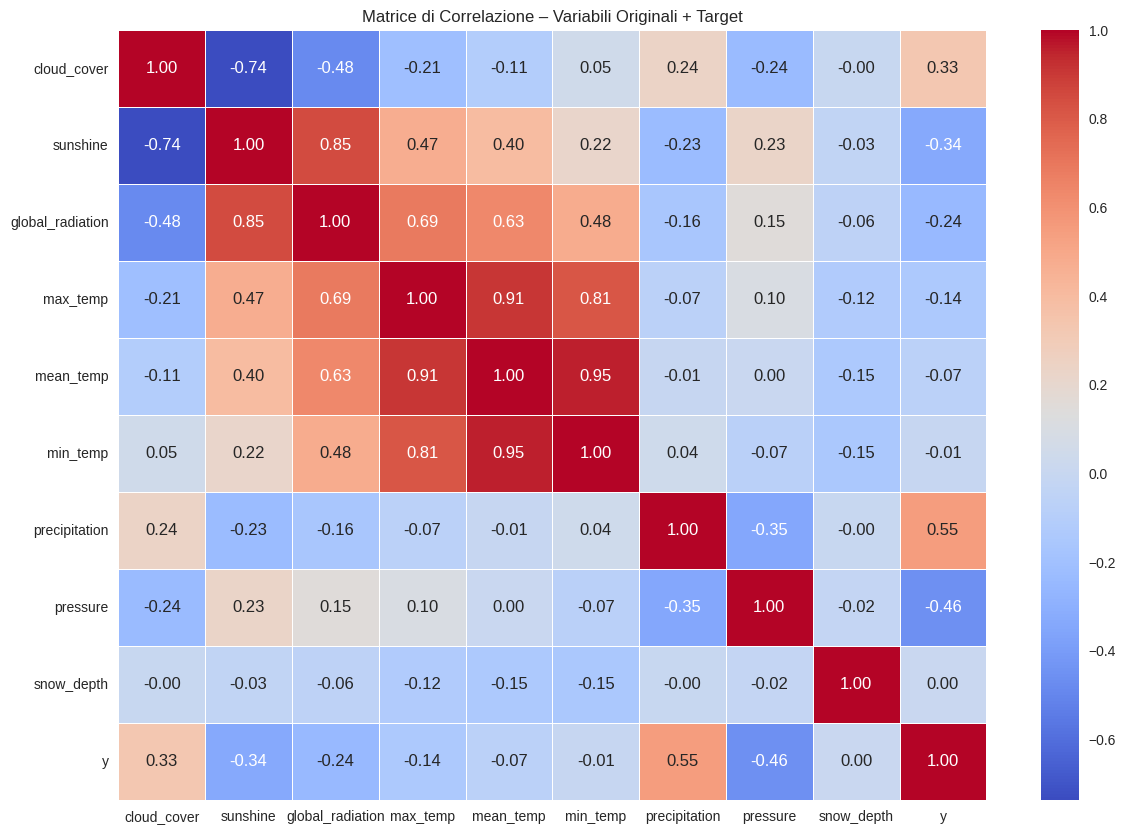

Numero finale di feature isolate per l'addestramento: 21


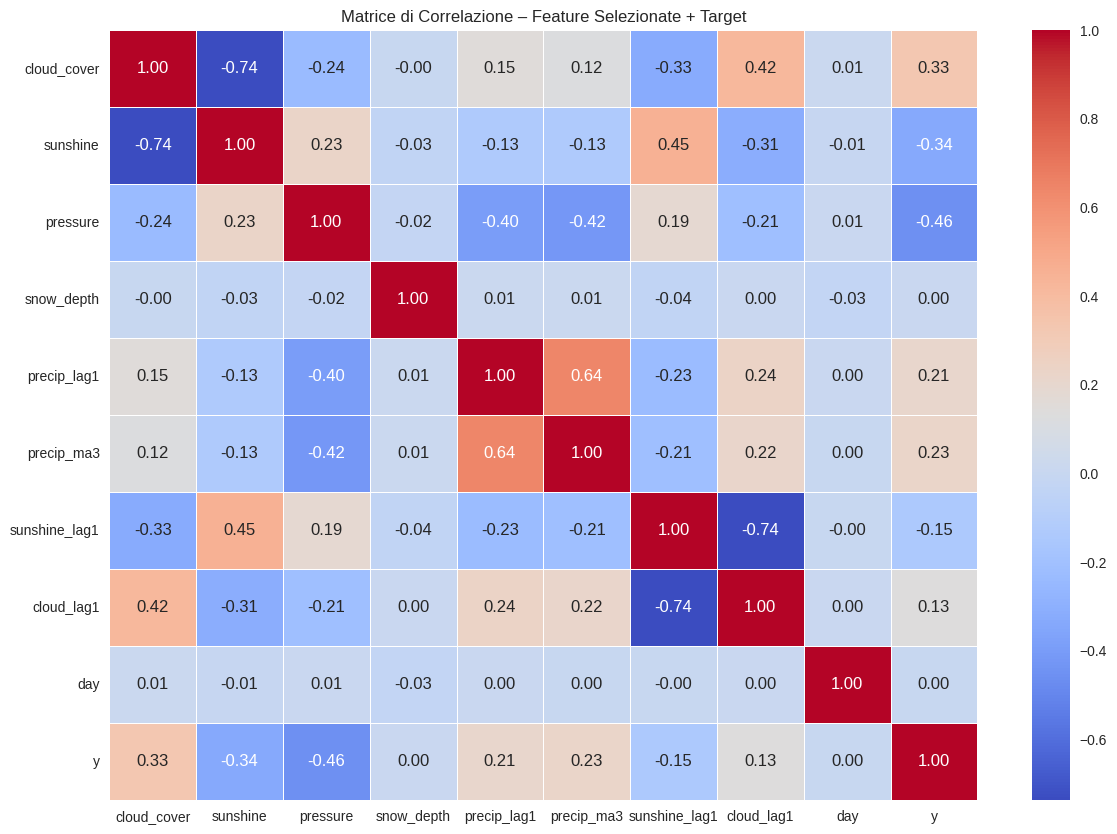

In [ ]:
cols_corr = ["cloud_cover", "sunshine", "global_radiation", "max_temp", "mean_temp", "min_temp", "precipitation", "pressure", "snow_depth", "y"]

plt.figure(figsize=(14, 10))
sns.heatmap(data[cols_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matrice di Correlazione – Variabili Originali + Target")
plt.show()

# Selezione finale delle feature (escludendo le variabili termiche correlate)
feature_columns = (
    ['cloud_cover', 'sunshine', 'pressure', 'snow_depth',
     'precip_lag1', 'precip_ma3', 'sunshine_lag1', 'cloud_lag1', 'day']
    + [col for col in data.columns if col.startswith('month_')]
)

X = data[feature_columns]
y = data['y']
print(f"Numero finale di feature isolate per l'addestramento: {len(feature_columns)}")

# Mappa di verifica post-selezione
features_check = ['cloud_cover', 'sunshine', 'pressure', 'snow_depth', 'precip_lag1', 'precip_ma3', 'sunshine_lag1', 'cloud_lag1', 'day', 'y']
plt.figure(figsize=(14, 10))
sns.heatmap(data[features_check].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matrice di Correlazione – Feature Selezionate + Target")
plt.show()

## 7. Ripartizione Temporale dei Dati (Train / Test Split)
Trattandosi di dati meteorologici sequenziali ordinati nel tempo, applichiamo uno split cronologico rigido per evitare il data leakage (impedendo al modello di "vedere il futuro"). Tutto ciò che è antecedente al **2019** costituirà il Training Set, mentre il biennio **2019-2020** viene isolato come Test Set cieco.

In [ ]:
train_mask = data['year'] < 2019
test_mask  = data['year'] >= 2019

X_train = X[train_mask].reset_index(drop=True)
y_train = y[train_mask].reset_index(drop=True)
X_test  = X[test_mask].reset_index(drop=True)
y_test  = y[test_mask].reset_index(drop=True)

print(f"Campioni nel Training set: {X_train.shape[0]}")
print(f"Campioni nel Test set finale: {X_test.shape[0]}")
print(f"\nDistribuzione del target nel training:\n{y_train.value_counts(normalize=True)}")

Campioni nel Training set: 14610
Campioni nel Test set finale: 731

Distribuzione del target nel training:
y
0    0.608077
1    0.391923
Name: proportion, dtype: float64


## 8. Configurazione dei Classificatori di Baseline
Configuriamo i 5 modelli scelti per l'analisi comparativa. Per compensare nativamente il leggero sbilanciamento del target (60/40) senza alterare la natura della serie storica con sovracampionamenti sintetici, introduciamo i pesi bilanciati via `class_weight` e `scale_pos_weight`.

In [ ]:
rs = 42

# Calcolo del rapporto classi per pesare correttamente XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

classifiers = {
    'LogisticRegression': LogisticRegression(random_state=rs, solver='liblinear', class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(random_state=rs, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=rs, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=rs, scale_pos_weight=neg/pos),
    'SVC': SVC(probability=True, random_state=rs, class_weight='balanced'),
}

## 9. Validazione Incrociata Temporale e Addestramento
Eseguiamo il ciclo computazionale della baseline. Incapsuliamo ogni modello dentro una `Pipeline` insieme allo scaler `MinMaxScaler`: in questo modo lo scaling viene calcolato fold per fold unicamente sul subset di train di `TimeSeriesSplit`, azzerando qualsiasi rischio di data leakage sui dati di validazione.

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

clf_names              = []
cv_means               = []
cv_stds                = []
test_accuracies        = []
confusion_matrices     = []
classification_reports = []
roc_aucs               = []
roc_fprs               = []
roc_tprs               = []
fitted_pipes           = {}

model_results = pd.DataFrame({'y_true': y_test.values})

def make_pipe(clf_instance):
    return Pipeline([
        ('scaler',     MinMaxScaler()),
        ('classifier', clf_instance)
    ])

for name, clf in classifiers.items():
    print(f"\n--- {name} ---")
    clf_names.append(name)

    # 1. Cross-validation cross-temporale
    pipe_cv = make_pipe(clf)
    scores  = cross_val_score(pipe_cv, X_train, y_train, cv=tscv, scoring='f1_weighted', n_jobs=-1)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"F1-weighted CV: {scores.mean():.4f} (+/- {scores.std():.4f})")

    # 2. Addestramento finale sul dataset pre-2018 completo
    pipe_final = make_pipe(clf)
    pipe_final.fit(X_train, y_train)
    fitted_pipes[name] = pipe_final

    # 3. Inferenza predittiva sul Test Set (2019-2020)
    y_pred = pipe_final.predict(X_test)
    model_results[name] = y_pred

    # Registrazione metriche di performance stabilite
    acc = accuracy_score(y_test, y_pred)
    test_accuracies.append(acc)
    confusion_matrices.append(confusion_matrix(y_test, y_pred))
    classification_reports.append(classification_report(y_test, y_pred))

    # Curve ROC
    y_proba = pipe_final.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_aucs.append(auc(fpr, tpr))
    roc_fprs.append(fpr)
    roc_tprs.append(tpr)

print("\n✓ Pipeline di baseline completata.")


--- LogisticRegression ---
F1-weighted CV: 0.7417 (+/- 0.0122)

--- DecisionTree ---
F1-weighted CV: 0.6696 (+/- 0.0084)

--- RandomForest ---
F1-weighted CV: 0.7409 (+/- 0.0114)

--- XGBoost ---
F1-weighted CV: 0.7213 (+/- 0.0092)

--- SVC ---
F1-weighted CV: 0.7410 (+/- 0.0105)

✓ Pipeline di baseline completata.


## 10. Barplot Comparativo della Cross-Validation
Aggreghiamo i punteggi medi della Cross-Validation temporale ed i relativi scostamenti quadratici medi in un DataFrame, proiettando le performance e la stabilità dei classificatori tramite un grafico a barre dotato di barre d'errore (`errorbar`).

            Algorithm   CV Mean    CV Std  Test Accuracy
0  LogisticRegression  0.741660  0.012184       0.766074
4                 SVC  0.741024  0.010508       0.770178
2        RandomForest  0.740892  0.011366       0.757866
3             XGBoost  0.721305  0.009220       0.738714
1        DecisionTree  0.669632  0.008415       0.648427


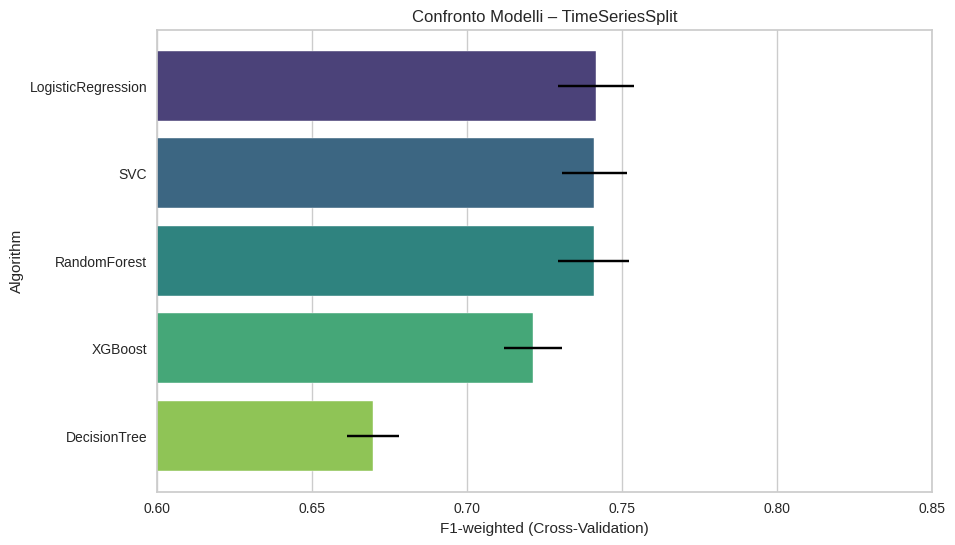

In [ ]:
cv_df = pd.DataFrame({
    'Algorithm':     clf_names,
    'CV Mean':       cv_means,
    'CV Std':        cv_stds,
    'Test Accuracy': test_accuracies
}).sort_values('CV Mean', ascending=False)

print(cv_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='CV Mean', y='Algorithm', data=cv_df, palette='viridis')
plt.errorbar(x=cv_df['CV Mean'], y=range(len(cv_df)), xerr=cv_df['CV Std'], fmt='none', ecolor='black', capsize=5)
plt.xlabel('F1-weighted (Cross-Validation)')
plt.title('Confronto Modelli – TimeSeriesSplit')
plt.xlim(0.6, 0.85)
plt.show()

## 11. Griglia delle Matrici di Confusione della Baseline
Generiamo un subplot multi-pannello per analizzare la distribuzione degli errori (Falsi Positivi e Falsi Negativi) commessi sul test set da ciascuno dei 5 algoritmi di base.

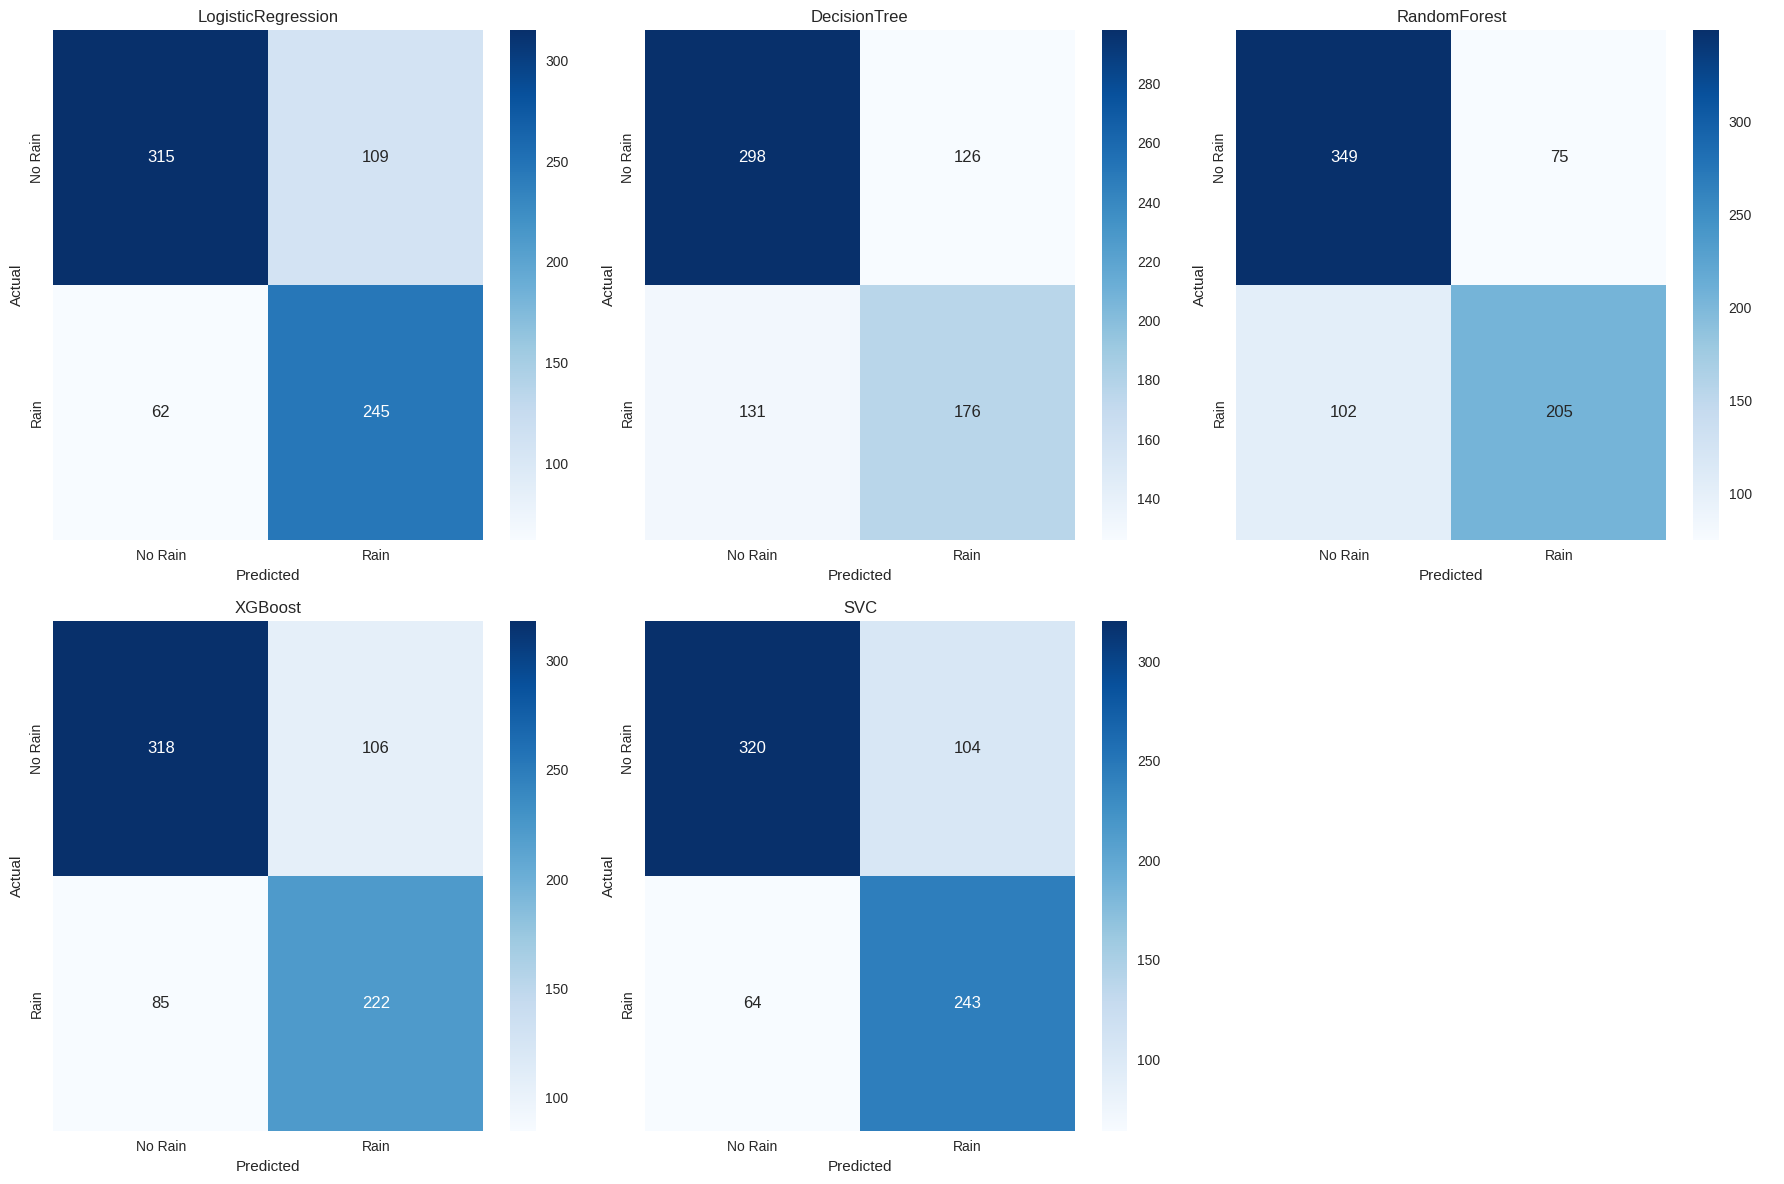

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, cm) in enumerate(zip(clf_names, confusion_matrices)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(len(clf_names), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 12. Classification Reports Analitici
Estraiamo i report di classificazione testuali estesi per valutare puntualmente i bilanciamenti di Precision e Recall sulle singole classi predittive.

In [ ]:
for i, name in enumerate(clf_names):
    print(f"\n=== {name} ===")
    print(classification_reports[i])


=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       424
           1       0.69      0.80      0.74       307

    accuracy                           0.77       731
   macro avg       0.76      0.77      0.76       731
weighted avg       0.78      0.77      0.77       731


=== DecisionTree ===
              precision    recall  f1-score   support

           0       0.69      0.70      0.70       424
           1       0.58      0.57      0.58       307

    accuracy                           0.65       731
   macro avg       0.64      0.64      0.64       731
weighted avg       0.65      0.65      0.65       731


=== RandomForest ===
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       424
           1       0.73      0.67      0.70       307

    accuracy                           0.76       731
   macro avg       0.75      0.75      0.75       731
we

## 13. Analisi e Confronto delle Curve ROC
Tracciamo le curve ROC di tutti i modelli per mappare l'andamento della sensibilità rispetto alla specificità, confrontando il valore geometrico dell'area sottesa alla curva (AUC).

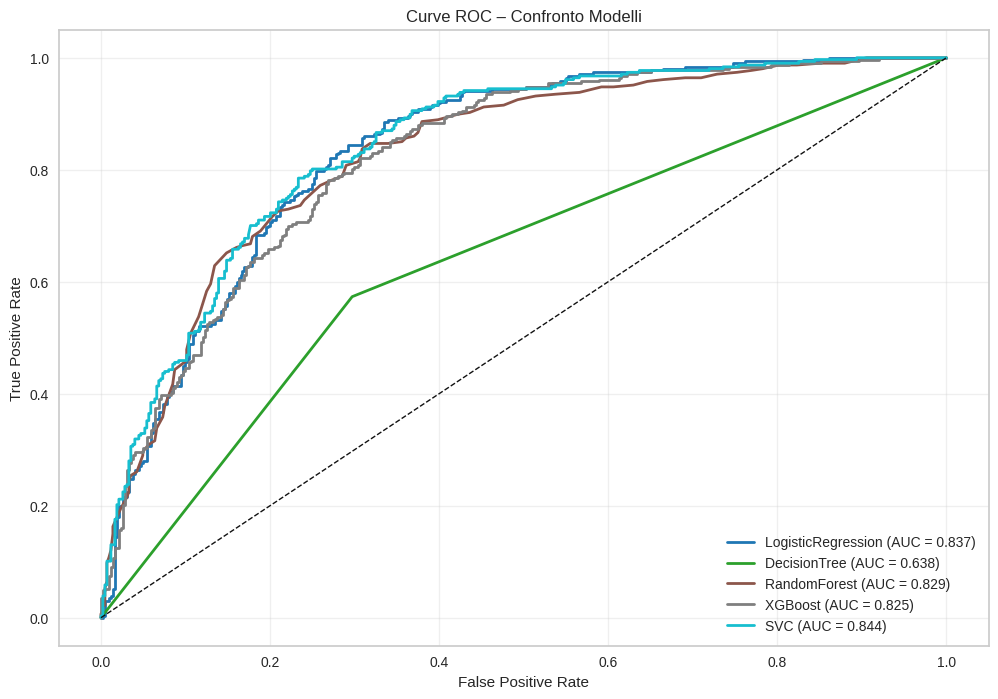

In [ ]:
plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(clf_names)))

for i, name in enumerate(clf_names):
    plt.plot(roc_fprs[i], roc_tprs[i], color=colors[i], lw=2, label=f'{name} (AUC = {roc_aucs[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curve ROC – Confronto Modelli')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## 14. Analisi di Correlazione tra le Predizioni
Analizziamo il grado di accordo tra le risposte binarie fornite dai classificatori sul test set. Una correlazione parziale o contenuta tra i modelli migliori giustifica l'implementazione di un sistema di voto (Ensemble).

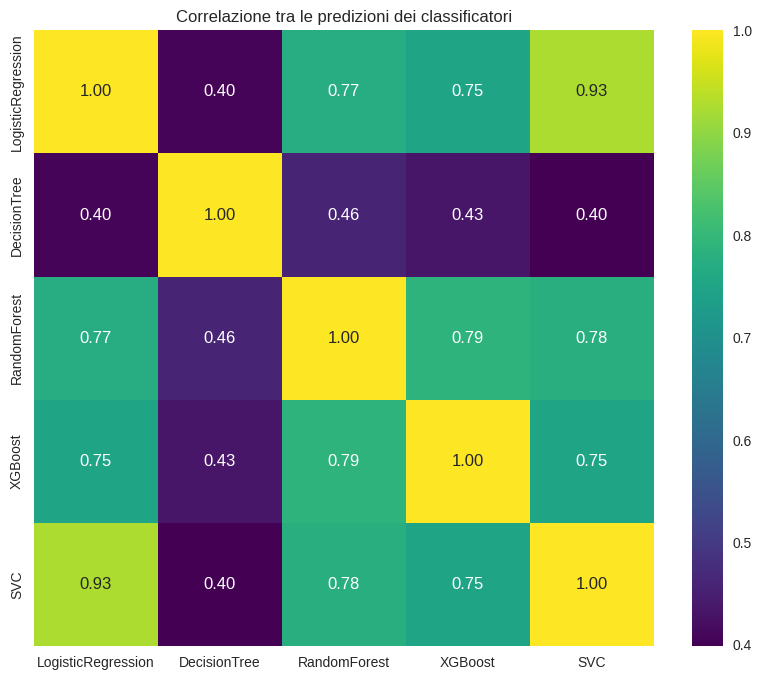

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(model_results.drop(columns=['y_true']).corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlazione tra le predizioni dei classificatori")
plt.show()

## 15. Ottimizzazione Iperparametri (GridSearchCV)
Isolati i due algoritmi top-performing (`RandomForest` e `XGBoost`), eseguiamo una ricerca esaustiva degli iperparametri migliori tramite `GridSearchCV` accoppiato a una validazione crociata temporale a 3 split.

In [ ]:
param_grids = {
    'RandomForest': {
        'classifier__n_estimators':      [50, 100],
        'classifier__max_depth':         [5, 8, None],
        'classifier__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'classifier__n_estimators':  [100, 200],
        'classifier__max_depth':     [3, 6],
        'classifier__learning_rate': [0.01, 0.1]
    }
}

tscv_grid   = TimeSeriesSplit(n_splits=3)
best_models = {}

for name in ['RandomForest', 'XGBoost']:
    print(f"\n=== GridSearch per {name} ===")
    pipe = make_pipe(classifiers[name])
    gs   = GridSearchCV(pipe, param_grids[name], cv=tscv_grid, scoring='f1_weighted', n_jobs=-1, verbose=1)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    print(f"Migliori parametri: {gs.best_params_}")
    print(f"F1-weighted CV:     {gs.best_score_:.4f}")


=== GridSearch per RandomForest ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Migliori parametri: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
F1-weighted CV:     0.7449

=== GridSearch per XGBoost ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Migliori parametri: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
F1-weighted CV:     0.7436


## 16. Costruzione dell'Ensemble (Voting Classifier)
Uniamo i due stimatori ottimizzati in un unico modello di Ensemble basato su Soft Voting. Il sistema effettuerà le predizioni pesando la media delle probabilità calcolate dai singoli sotto-modelli.


=== VOTING CLASSIFIER ===
Accuracy:            0.7551
F1-score (macro):    0.7503
F1-score (weighted): 0.7558

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       424
           1       0.70      0.73      0.72       307

    accuracy                           0.76       731
   macro avg       0.75      0.75      0.75       731
weighted avg       0.76      0.76      0.76       731



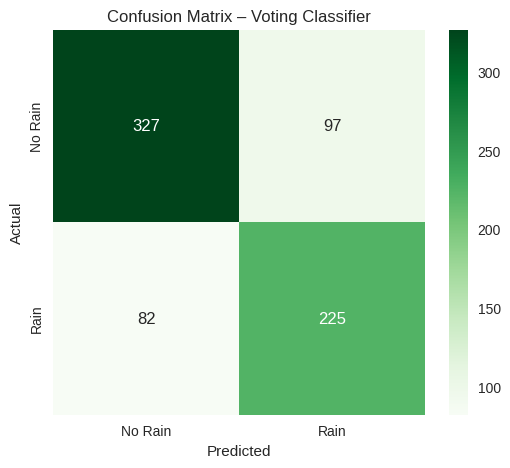

In [ ]:
estimators  = [(name, best_models[name]) for name in best_models.keys()]
voting_clf  = VotingClassifier(estimators=estimators, voting='soft')
voting_clf.fit(X_train, y_train)

y_pred_voting  = voting_clf.predict(X_test)
y_proba_voting = voting_clf.predict_proba(X_test)[:, 1]

print("\n=== VOTING CLASSIFIER ===")
print(f"Accuracy:            {accuracy_score(y_test, y_pred_voting):.4f}")
print(f"F1-score (macro):    {f1_score(y_test, y_pred_voting, average='macro'):.4f}")
print(f"F1-score (weighted): {f1_score(y_test, y_pred_voting, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_voting))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_voting), annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Voting Classifier')
plt.show()

## 17. Diagnostica Avanzata (Yellowbrick e Curve di Apprendimento)
Sfruttiamo le API di Yellowbrick per tracciare i grafici avanzati dell'Ensemble finale: la curva ROC cumulativa, la curva di Precision-Recall e la **Learning Curve** (curva di apprendimento) dinamica basata su 5 split di cross-validation temporale.

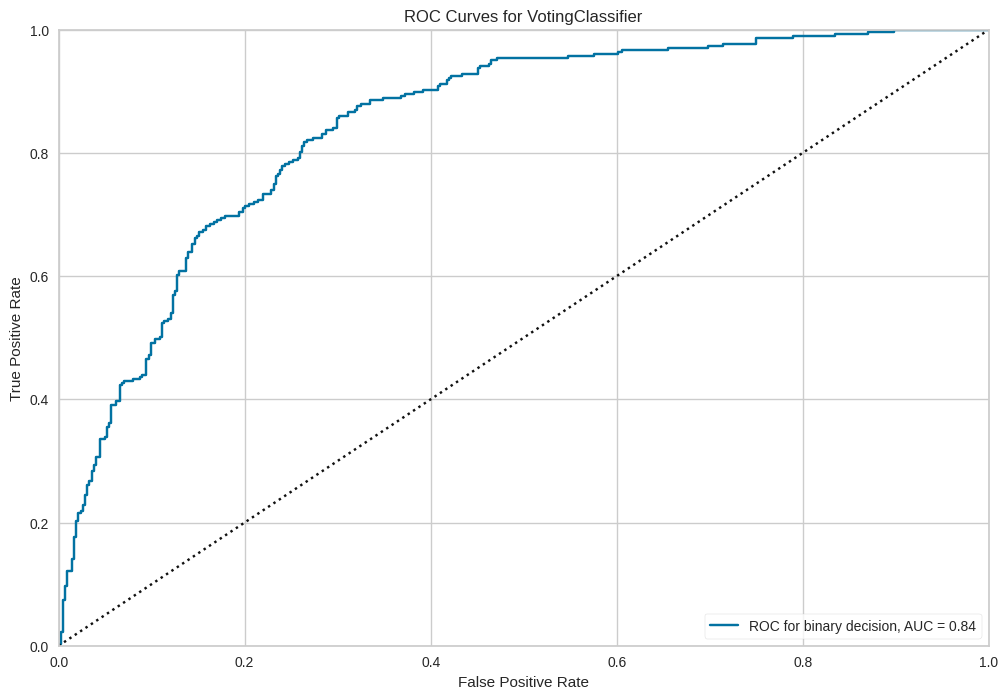

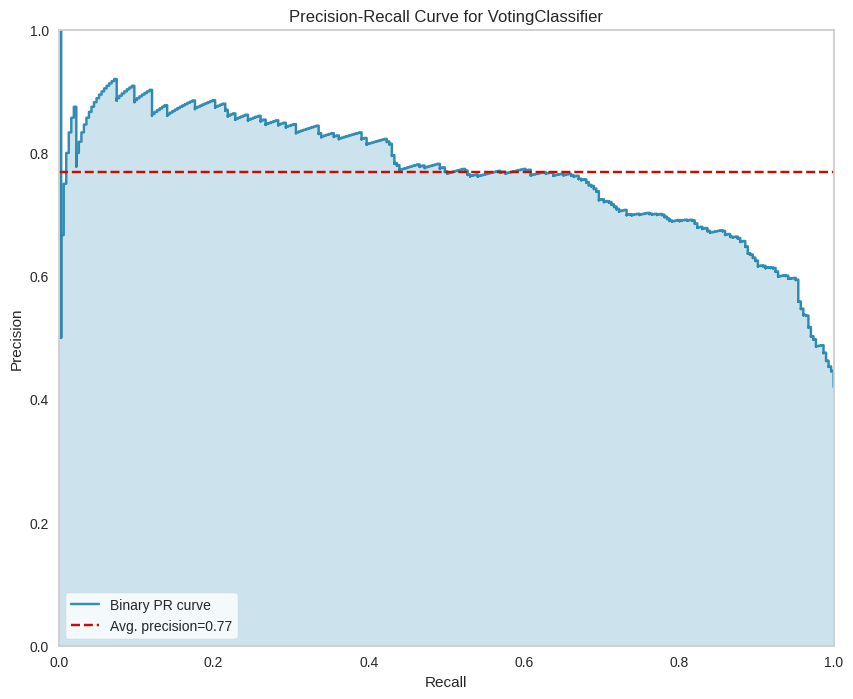

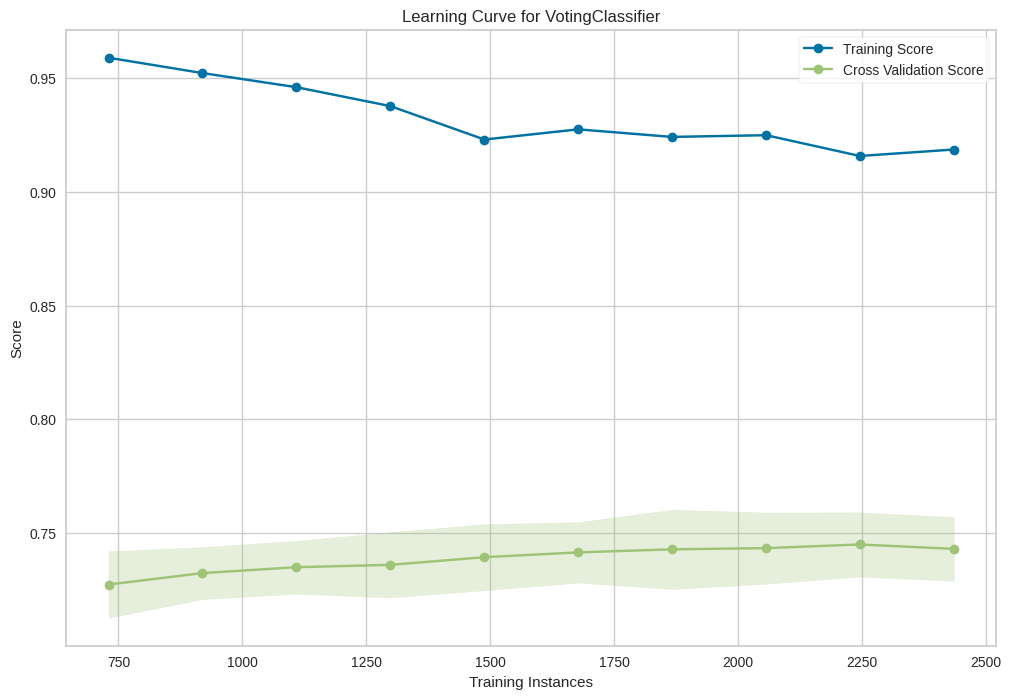

<Axes: title={'center': 'Learning Curve for VotingClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [ ]:
# 1. Curva ROC Avanzata
plt.figure(figsize=(12, 8))
visualizer = ROCAUC(voting_clf, classes=["no_precipitation", "precipitation"], micro=False, macro=False, binary=True)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

# 2. Curva Precision-Recall Avanzata
plt.figure(figsize=(10, 8))
viz = PrecisionRecallCurve(voting_clf)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show()

# 3. Learning Curve
plt.figure(figsize=(12, 8))
visualizer_lc = LearningCurve(
    voting_clf,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='f1_weighted',
    train_sizes=np.linspace(0.3, 1.0, 10),
    n_jobs=-1
)
visualizer_lc.fit(X_train, y_train)
visualizer_lc.show()

## 18. Ottimizzazione della Soglia di Decisione
Svincoliamo la classificazione dalla soglia standard a `0.5`. Analizzando geometricamente la curva Precision-Recall sul test set, identifichiamo la soglia esatta in grado di massimizzare l'F1-score globale del modello diagnostico.

Soglia default (0.5): F1 = 0.7154
Soglia ottimale (0.377): F1 = 0.7556

=== Prestazioni con soglia ottimale ===
              precision    recall  f1-score   support

           0       0.88      0.68      0.77       424
           1       0.66      0.88      0.76       307

    accuracy                           0.76       731
   macro avg       0.77      0.78      0.76       731
weighted avg       0.79      0.76      0.76       731



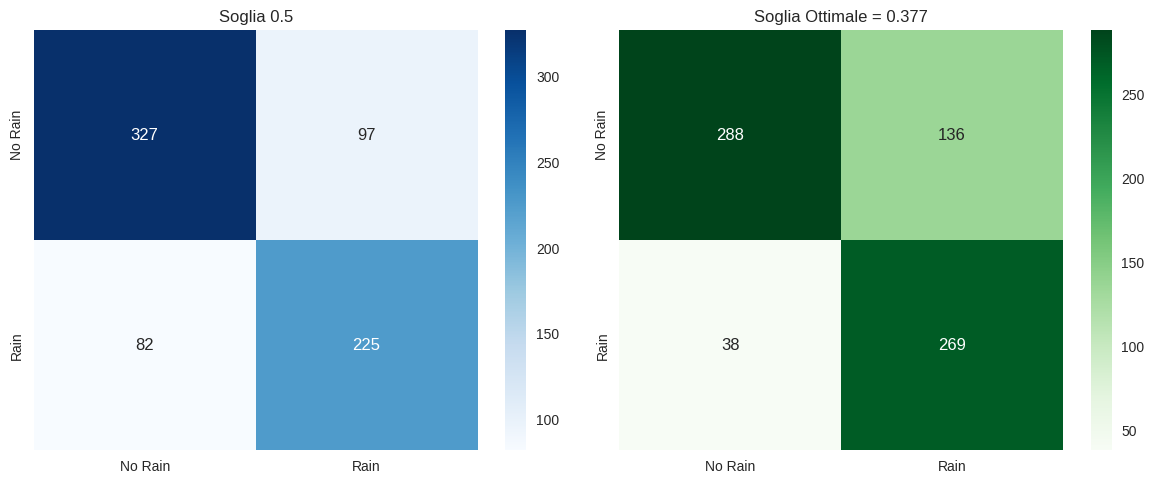

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_voting)
f1_scores_thr  = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx       = np.argmax(f1_scores_thr[:-1])
best_threshold = thresholds[best_idx]

print(f"Soglia default (0.5): F1 = {f1_score(y_test, y_proba_voting >= 0.5):.4f}")
print(f"Soglia ottimale ({best_threshold:.3f}): F1 = {f1_scores_thr[best_idx]:.4f}")

y_pred_adj = (y_proba_voting >= best_threshold).astype(int)
print("\n=== Prestazioni con soglia ottimale ===")
print(classification_report(y_test, y_pred_adj))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_proba_voting >= 0.5), annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
ax1.set_title('Soglia 0.5')

sns.heatmap(confusion_matrix(y_test, y_pred_adj), annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
ax2.set_title(f'Soglia Ottimale = {best_threshold:.3f}')
plt.tight_layout()
plt.show()

## 19. Inferenza Globale ed Esportazione Predizioni
Eseguiamo l'inferenza probabilistica estesa sull'intero set di dati storici di Londra tramite il Voting Classifier. Generiamo le colonne finali contenenti le classi predette e la probabilità di pioggia, esportando i risultati nel file `predictions.csv`, scaricato automaticamente in locale.

In [ ]:
X_all = data[feature_columns]

data['predicted_rain'] = voting_clf.predict(X_all)
data['prob_rain']      = voting_clf.predict_proba(X_all)[:, 1]

print("Distribuzione predizioni sull'intero dataset:")
print(data['predicted_rain'].value_counts(normalize=True))

data[['date', 'precipitation', 'y', 'predicted_rain', 'prob_rain']].to_csv('predictions.csv', index=False)
print("\n✓ Risultati salvati in 'predictions.csv'")

# Import locale esplicito di sicurezza per Colab
from google.colab import files
files.download('predictions.csv')

Distribuzione predizioni sull'intero dataset:
predicted_rain
0    0.574669
1    0.425331
Name: proportion, dtype: float64

✓ Risultati salvati in 'predictions.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>